# CDS6314 DATA MINING (TRIMESTER 2530)
## PROJECT - 30%
### Title: Hotel Booking Cancellation Prediction using Machine Learning
#### Group P3
#### Class Section: TC1L/TT2L

#### Import libraries

In [195]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.pipeline import Pipeline
from sklearn.base import clone
from imblearn.over_sampling import SMOTENC

#### Load csv file

In [196]:
# read dataset
data = pd.read_csv("hotel_bookings.csv")
df = data.copy()

## Data Exploration

In [197]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [198]:
# rows and columns in this dataset
row, column = df.shape
print(f'Total number of sample : {row}')
print(f'Total number of feature : {column}')

Total number of sample : 119390
Total number of feature : 32


In [199]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [200]:
# attributes type
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [201]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [202]:
# check object columns for "dirty" data
obj_cols = df.select_dtypes(include=["object"]).columns

for c in obj_cols:
    uniques = df[c].dropna().unique()
    n_unique = len(uniques)

    print(f"\n--- {c} ---")
    print(f"unique count: {n_unique}")

    # show first 10 unique values
    show_n = 15
    print("first 10 uniques:", uniques[:show_n])

    # how many left after the first 10
    remaining = max(0, n_unique - show_n)
    print(f"other uniques left: {remaining}")



--- hotel ---
unique count: 2
first 10 uniques: ['Resort Hotel' 'City Hotel']
other uniques left: 0

--- arrival_date_month ---
unique count: 12
first 10 uniques: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
other uniques left: 0

--- meal ---
unique count: 5
first 10 uniques: ['BB' 'FB' 'HB' 'SC' 'Undefined']
other uniques left: 0

--- country ---
unique count: 177
first 10 uniques: ['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN']
other uniques left: 162

--- market_segment ---
unique count: 8
first 10 uniques: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']
other uniques left: 0

--- distribution_channel ---
unique count: 5
first 10 uniques: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']
other uniques left: 0

--- reserved_room_type ---
unique count: 10
first 10 uniques: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']
other un

In [203]:
# check is there booking detail with no guest and no days
zero_guest=df[df[['adults', 'children', 'babies']].sum(axis=1)==0]
zero_days = df[df[['stays_in_weekend_nights','stays_in_week_nights']].sum(axis=1) == 0]

print(zero_guest.shape[0])
print(zero_days.shape[0])

180
715


In [204]:
# check dupplicated rows
print("Total duplicated rows: ", sum(df.duplicated()))

Total duplicated rows:  31994


In [205]:
# check missing value
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [206]:
# percentage of null value
df.isnull().sum()/df.shape[0]

hotel                             0.000000
is_canceled                       0.000000
lead_time                         0.000000
arrival_date_year                 0.000000
arrival_date_month                0.000000
arrival_date_week_number          0.000000
arrival_date_day_of_month         0.000000
stays_in_weekend_nights           0.000000
stays_in_week_nights              0.000000
adults                            0.000000
children                          0.000034
babies                            0.000000
meal                              0.000000
country                           0.004087
market_segment                    0.000000
distribution_channel              0.000000
is_repeated_guest                 0.000000
previous_cancellations            0.000000
previous_bookings_not_canceled    0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
deposit_type                      0.000000
agent      

## Data Preprocessing

In [207]:
# remove duplicate data
df = df.drop_duplicates()
print("Total duplicated rows: ", sum(df.duplicated()))

Total duplicated rows:  0


In [208]:
# drop strong target leakage column (reservation_status, reservation_status_date)
df = df.drop(columns = ["reservation_status", "reservation_status_date"])
# drop company since missing value > 30%
df.drop('company',inplace=True, axis=1)

print("Columns after dropping:", df.shape[1])
print("Number of columns = ", df.shape[1])
df.columns

Columns after dropping: 29
Number of columns =  29


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

In [209]:
# fill in missing value 
# children = 0
# country = Unknown
# agent with missing value consider no agent the convert to bool with new columns, then drop the agent column
# has_agent (1 = has agent, 0 = no agent)
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

# fill missing agent with 0 
df["agent"] = df["agent"].fillna(0).astype(int)

# convert hotel into bool
df["is_city_hotel"] = df["hotel"].eq("City Hotel")  # True = City Hotel, False = Resort Hotel

# replace undefined meal with the mode
mode_meal = df["meal"].mode(dropna=True)[0]
df["meal"] = df["meal"].replace("Undefined", mode_meal)

#replace undefined market_segment with the mode
mode_market_segment = df["market_segment"].mode(dropna=True)[0]
df["market_segment"] = df["market_segment"].replace("Undefined", mode_market_segment)

#replace undefined mode_distribution_channel with the mode
mode_distribution_channel = df["distribution_channel"].mode(dropna=True)[0]
df["distribution_channel"] = df["distribution_channel"].replace("Undefined", mode_distribution_channel)

# Because the country column has many unique values, it can cause the curse of dimensionality
# we group it into Local and International. Since the hotel is in Portugal, PRT = Local (1) and all other countries = International (0).
df['is_prt'] = (df['country'] == 'PRT').astype(bool)

# has_agent: True if agent > 0, else False
df["has_agent"] = df["agent"] > 0
df[["agent", "has_agent",'hotel','is_city_hotel','country','is_prt']].head()

,agent,has_agent,hotel,is_city_hotel,country,is_prt
0,0,False,Resort Hotel,False,PRT,True
1,0,False,Resort Hotel,False,PRT,True
2,0,False,Resort Hotel,False,GBR,False
3,304,True,Resort Hotel,False,GBR,False
4,240,True,Resort Hotel,False,GBR,False


In [210]:
#drop agent and hotel since the detail is convert into has_agent and is city hotel
df.drop(columns=['agent','hotel','country'],inplace=True, axis=1)
for c in df[['market_segment','meal','distribution_channel']]:
    print(f"\n--- {c} ---")
    print(df[c].dropna().unique())

print("Number of columns = ", df.shape[1])
print(f'has_agent type : {df["has_agent"].dtypes}')
print(f'is_city_hotel type : {df["is_city_hotel"].dtypes}')
print(f'is_prt type : {df["is_prt"].dtypes}')


--- market_segment ---
['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Aviation']

--- meal ---
['BB' 'FB' 'HB' 'SC']

--- distribution_channel ---
['Direct' 'Corporate' 'TA/TO' 'GDS']
Number of columns =  29
has_agent type : bool
is_city_hotel type : bool
is_prt type : bool


In [211]:
# check if there's is any more missing value
print(f'Total missing value in df : {df.isna().sum().sum()}')

Total missing value in df : 0


In [212]:
#convert type into correct type
bool_cols = ["is_canceled", "is_repeated_guest"]
df[bool_cols] = df[bool_cols].astype(bool)
df.children = df.children.astype(int)
print(df[bool_cols].dtypes)
print(f'childer : {df['children'].dtypes}')

is_canceled          bool
is_repeated_guest    bool
dtype: object
childer : int64


In [213]:
# invalid rows or outliers (weird data)
# (guest_sum = 0 but adults, children, babies > 0) remove instead of recalculate because it's data mistake
# recalculate might cause fake information and make model learn wrong pattern

print("Rows before cleaning:", df.shape[0])
zero_guest=df[df[['adults', 'children', 'babies']].sum(axis=1)==0]
df.drop(zero_guest.index, inplace=True)
zero_days = df[df[['stays_in_weekend_nights','stays_in_week_nights']].sum(axis=1) == 0]
df.drop(zero_days.index, inplace=True)
print("Rows after cleaning:", df.shape[0])

Rows before cleaning: 87396
Rows after cleaning: 86639


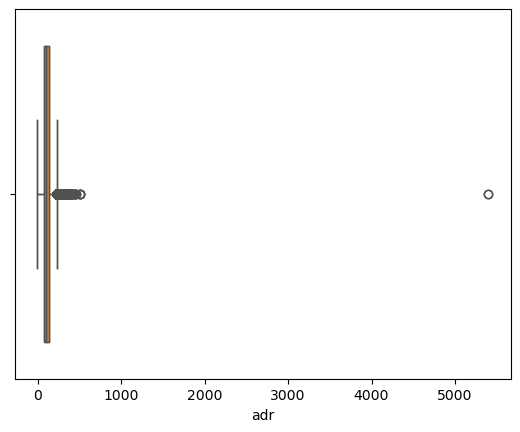

In [214]:
# show extreme adr
sns.boxplot(x=df['adr'])
ax = sns.boxplot(x=df['adr'])

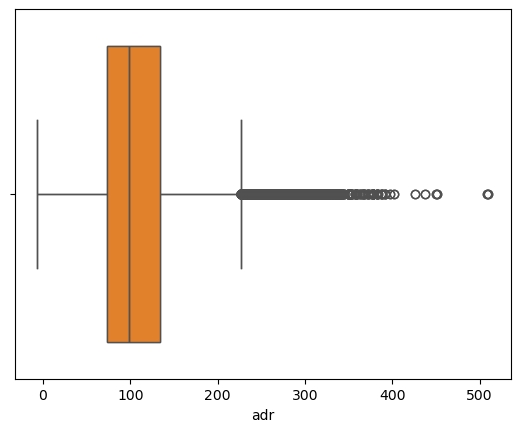

In [215]:
# remove extreme adr
df = df[df["adr"]<5000]
sns.boxplot(x=df['adr'])
ax = sns.boxplot(x=df['adr'])

In [216]:
# add stays in weekday and weekend into new columns: total stay nights
df["total_stay_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# get total number of people in booking (double confirm)
# treat guest_sum as helper to filter bad rows
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# convert months into numbers (1 to 12)
month_map = {m: i for i, m in enumerate(
    ["January","February","March","April","May","June","July","August",
     "September","October","November","December"], start=1
)}

# make new column arrival_month
df["arrival_month"] = df["arrival_date_month"].map(month_map).astype(int)

df[["stays_in_weekend_nights", "stays_in_week_nights", "total_stay_nights",
    "adults", "children", "babies", "total_guests",
    "arrival_date_month", "arrival_month"]].head(10)

,stays_in_weekend_nights,stays_in_week_nights,total_stay_nights,adults,children,babies,total_guests,arrival_date_month,arrival_month
2,0,1,1,1,0,0,1,July,7
3,0,1,1,1,0,0,1,July,7
4,0,2,2,2,0,0,2,July,7
6,0,2,2,2,0,0,2,July,7
7,0,2,2,2,0,0,2,July,7
8,0,3,3,2,0,0,2,July,7
9,0,3,3,2,0,0,2,July,7
10,0,4,4,2,0,0,2,July,7
11,0,4,4,2,0,0,2,July,7
12,0,4,4,2,0,0,2,July,7


In [217]:
# remove arrival_date_month
df = df.drop(columns=["arrival_date_month"])

In [218]:
print(df.dtypes)

is_canceled                          bool
lead_time                           int64
arrival_date_year                   int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                               object
market_segment                     object
distribution_channel               object
is_repeated_guest                    bool
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list                int64
customer_type                      object
adr                               float64
required_car_parking_spaces       

In [219]:
df.to_csv("df_cleaned.csv", index=False)

**Preprocessing for modeling**

In [220]:
df_cleaned = pd.read_csv('df_cleaned.csv')
bool_cols = df_cleaned.select_dtypes(include=["bool"]).columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)


In [221]:
# is_canceled = target column
# X = all other columns
# y = label column (1 = canceled, 0 = not canceled)
X = df_cleaned.drop(columns=["is_canceled"])
y = df_cleaned["is_canceled"]

# Step 1: 80% train, 20% temp (will become val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Step 2: split temp 20% into 10% val and 10% test (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, y_train.shape)  # 80%
print("Val:  ", X_val.shape, y_val.shape)      # 10%
print("Test: ", X_test.shape, y_test.shape)    # 10%

Train: (69310, 30) (69310,)
Val:   (8664, 30) (8664,)
Test:  (8664, 30) (8664,)


In [222]:
#save original X_train, X_val and X_test
ori_X_train =  X_train.copy()
ori_X_val =  X_val.copy()
ori_X_test= X_test.copy()

In [223]:
cat_cols = df_cleaned.select_dtypes(include=["object", "category"]).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str))    
    X_test[col]  = le.transform(X_test[col].astype(str))   
    label_encoders[col] = le

In [224]:
scale_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_stay_nights",
    "total_guests"
]
scaler = MinMaxScaler(feature_range=(0, 1))

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [225]:
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols]
smotenc = SMOTENC(categorical_features=cat_feature_indices, random_state=42, k_neighbors=5,sampling_strategy=0.7)
print(X_train.columns[cat_feature_indices].tolist())

['meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## EDA

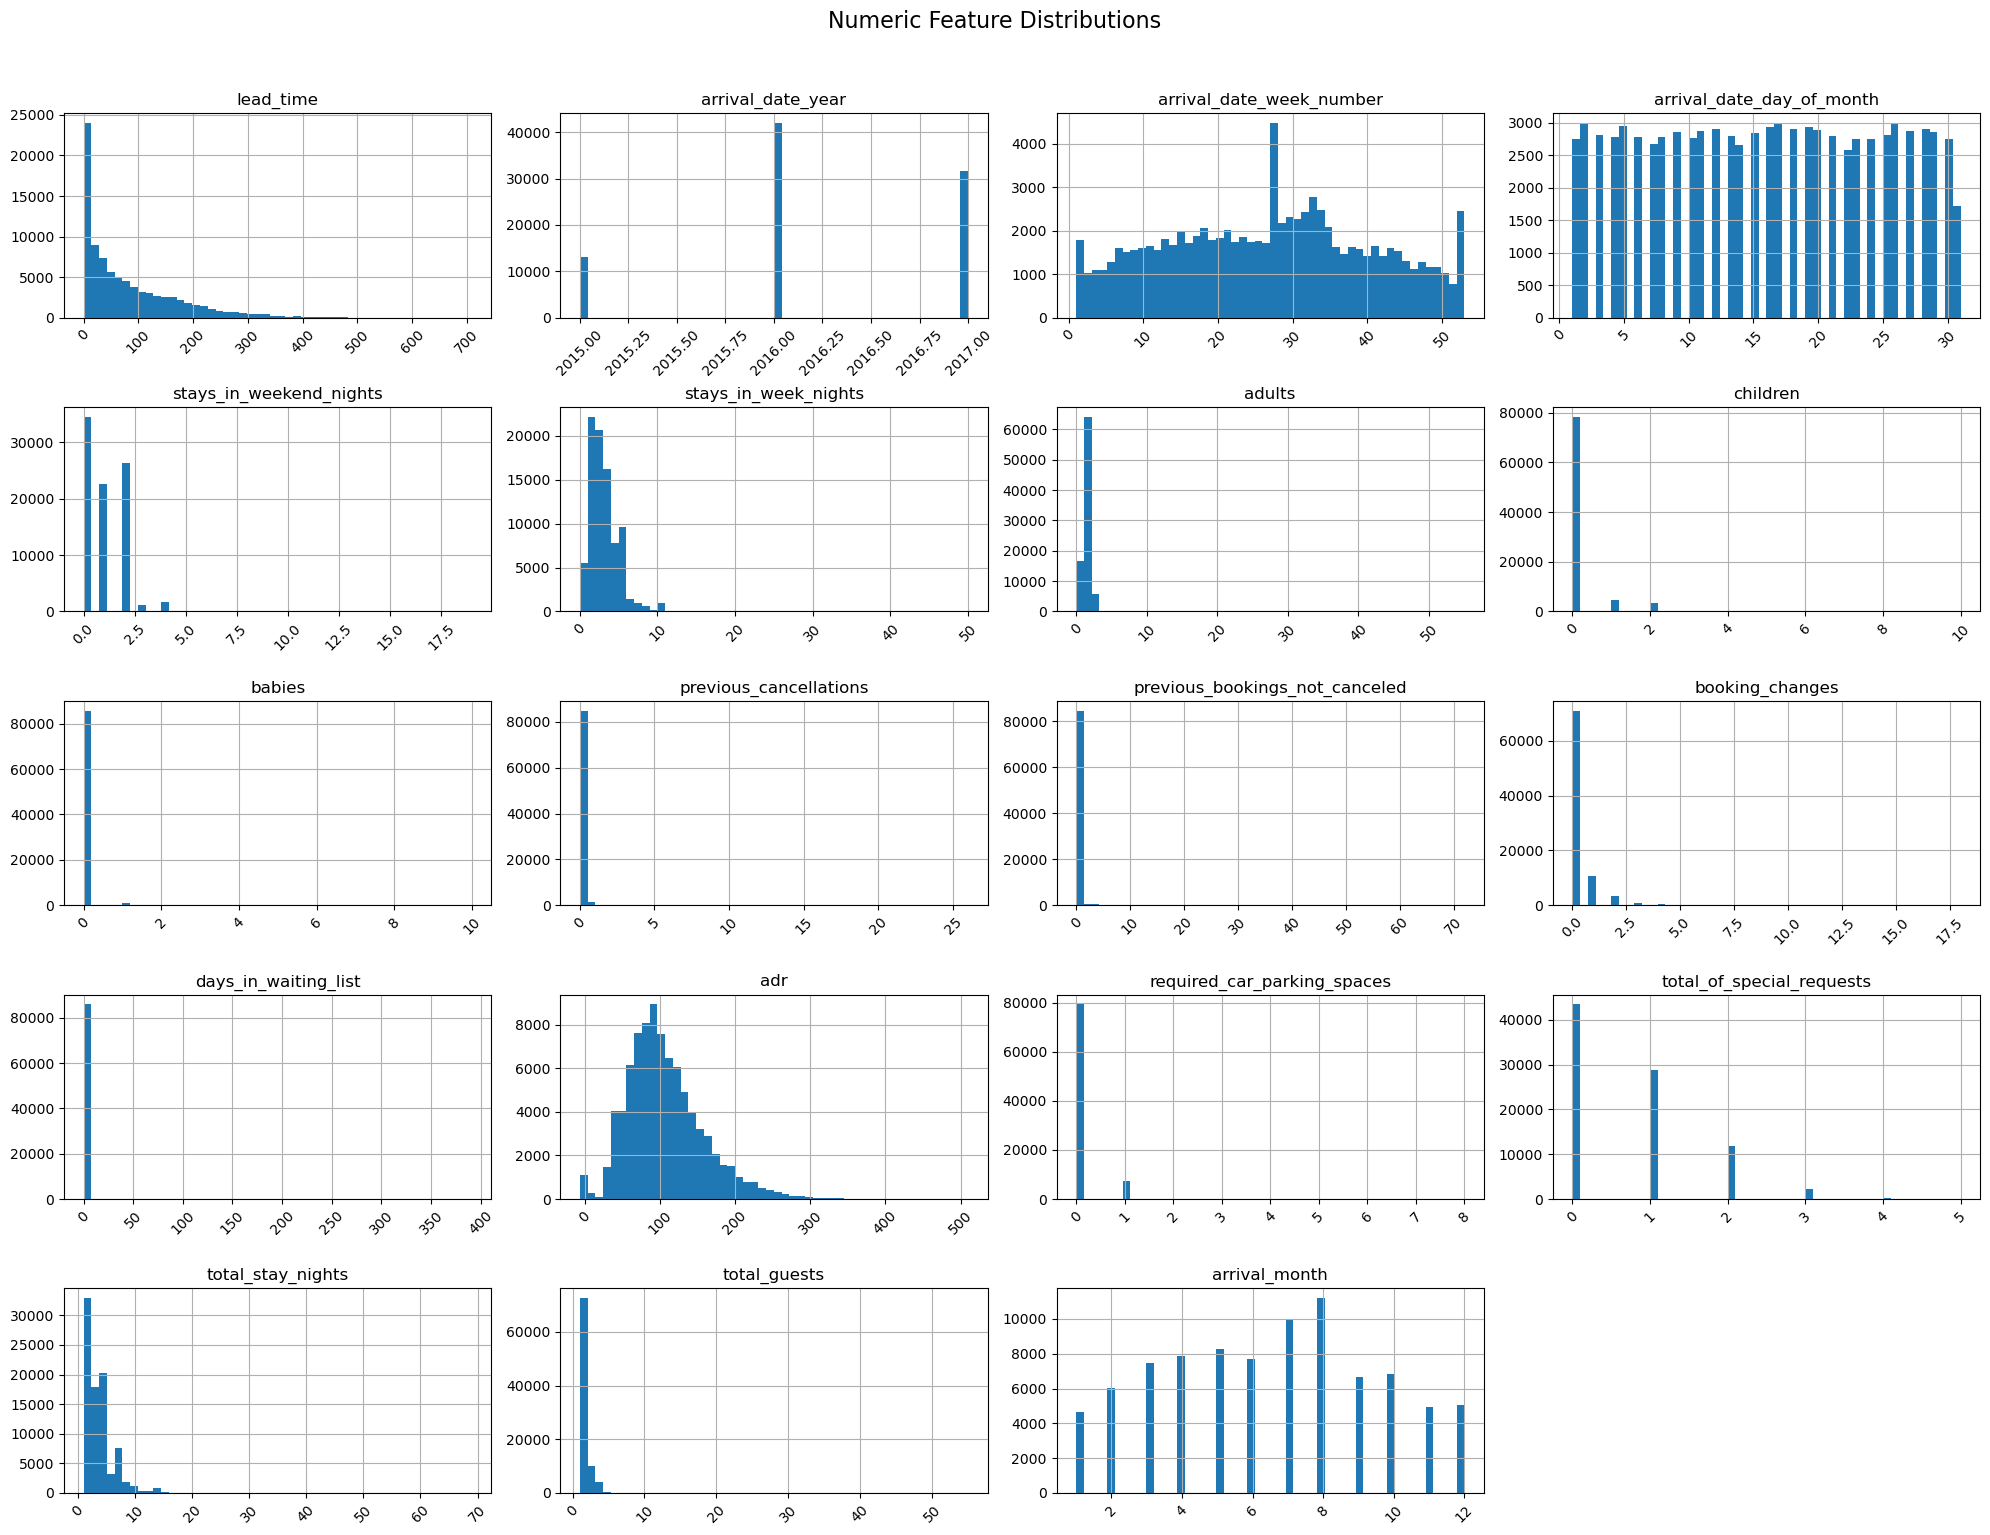

In [226]:
# ============================================
#  NUMERICAL DISTRIBUTIONS
# ============================================
num_df = df.select_dtypes(include=["float64", "int64"])

axes = num_df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Numeric Feature Distributions", fontsize=16, y=1.02)

for ax in axes.flatten():
    ax.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()

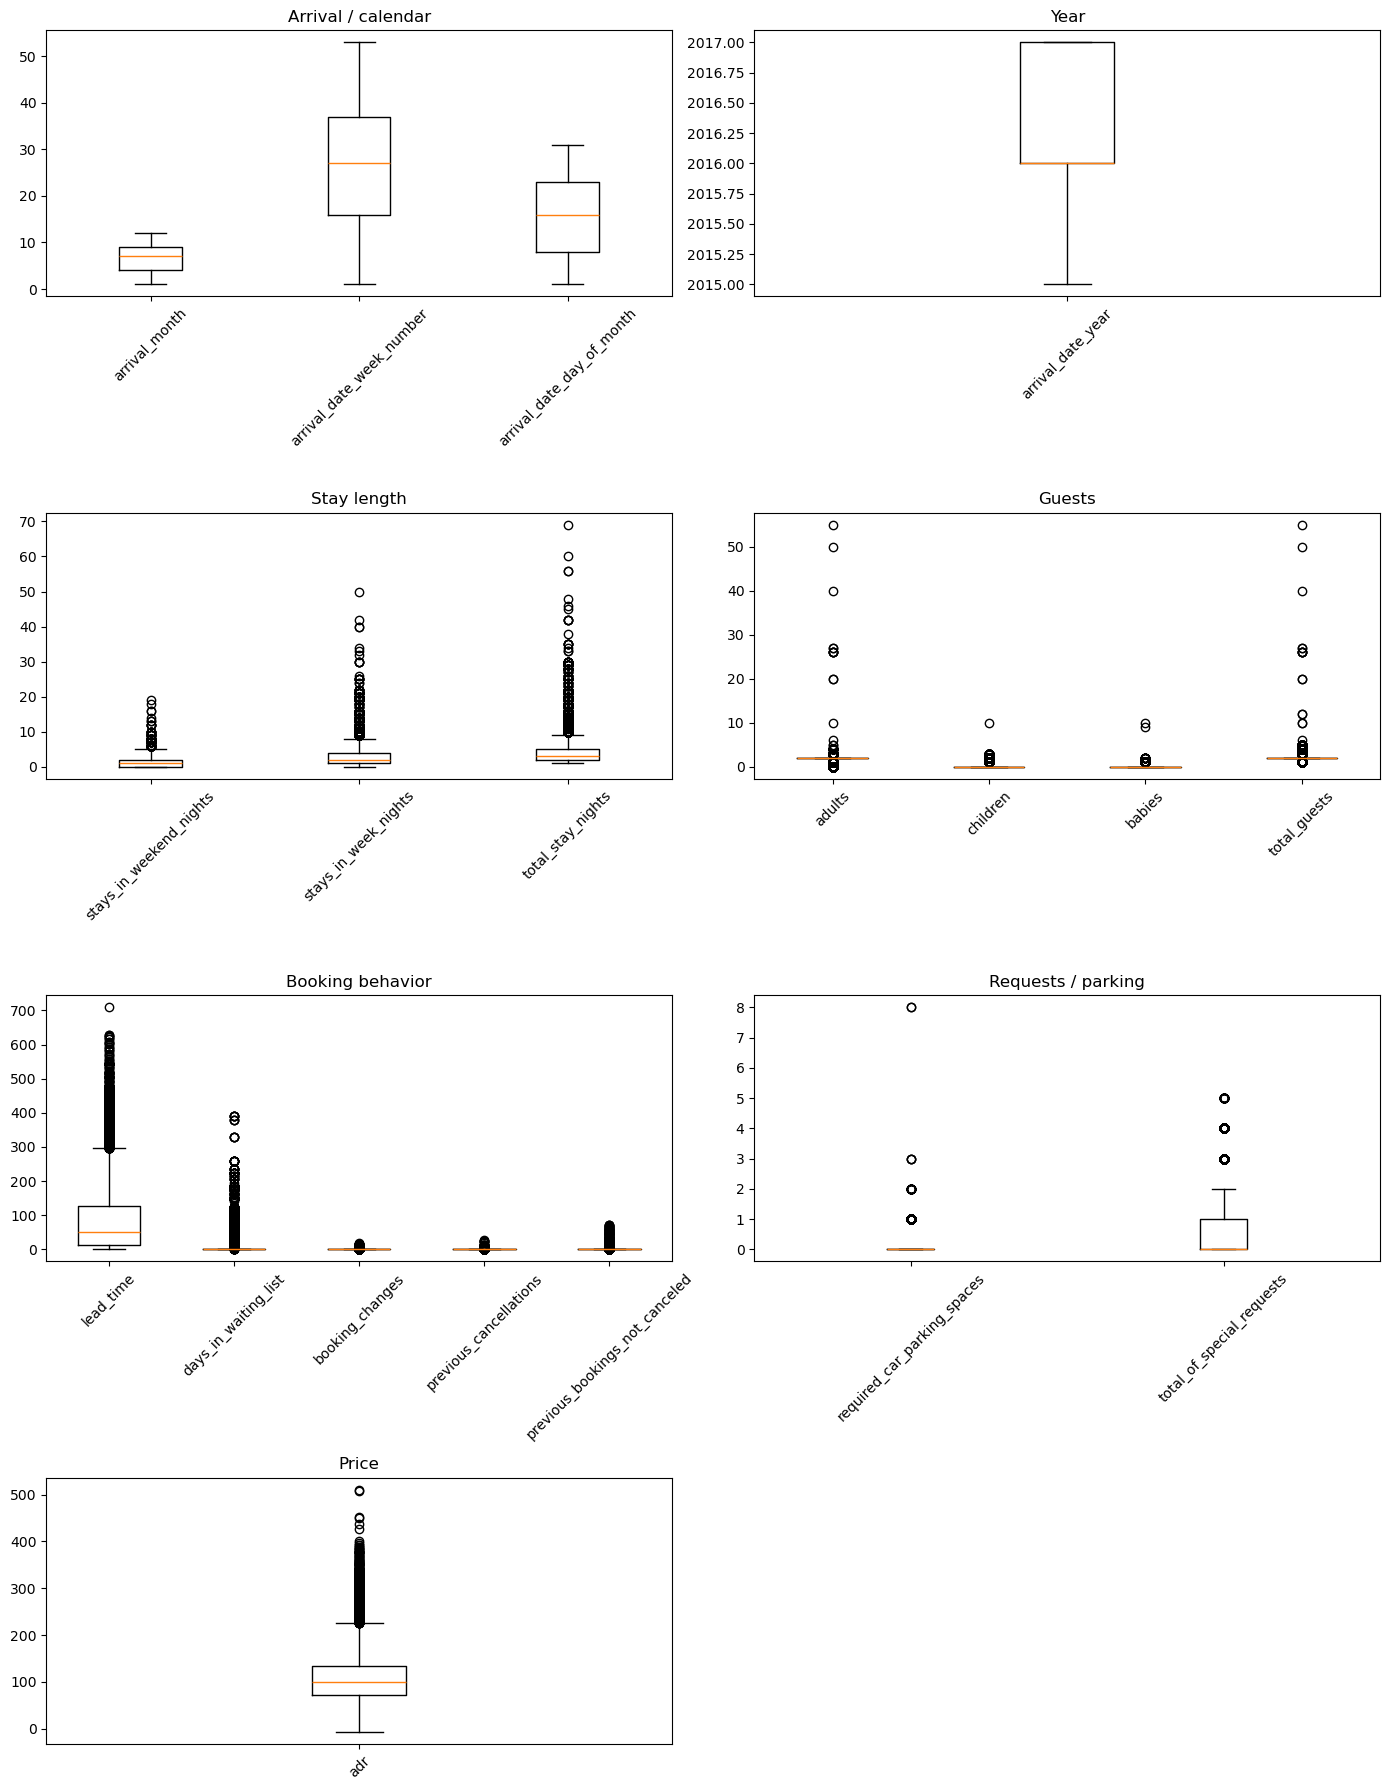

In [227]:
# ============================================
#  OUTLIER DETECTION
# ============================================
groups = {
    "Arrival / calendar": [
        "arrival_month",
        "arrival_date_week_number",
        "arrival_date_day_of_month"
    ],
    "Year": ["arrival_date_year"],  
    "Stay length": [
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "total_stay_nights"
    ],
    "Guests": [
        "adults", "children", "babies", "total_guests"
    ],
    "Booking behavior": [
        "lead_time", "days_in_waiting_list", "booking_changes",
        "previous_cancellations", "previous_bookings_not_canceled"
    ],
    "Requests / parking": [
        "required_car_parking_spaces", "total_of_special_requests"
    ],
    "Price": ["adr"],
}

# keep only columns that exist in your df
groups = {k: [c for c in v if c in df.columns] for k, v in groups.items()}
groups = {k: v for k, v in groups.items() if len(v) > 0}

n_groups = len(groups)
cols_per_row = 2
n_rows = int(np.ceil(n_groups / cols_per_row))

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(14, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (title, cols) in zip(axes, groups.items()):
    data = [df[c].dropna().values for c in cols]
    ax.boxplot(data, tick_labels=cols, showfliers=True)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

# remove extra empty axes
for ax in axes[len(groups):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


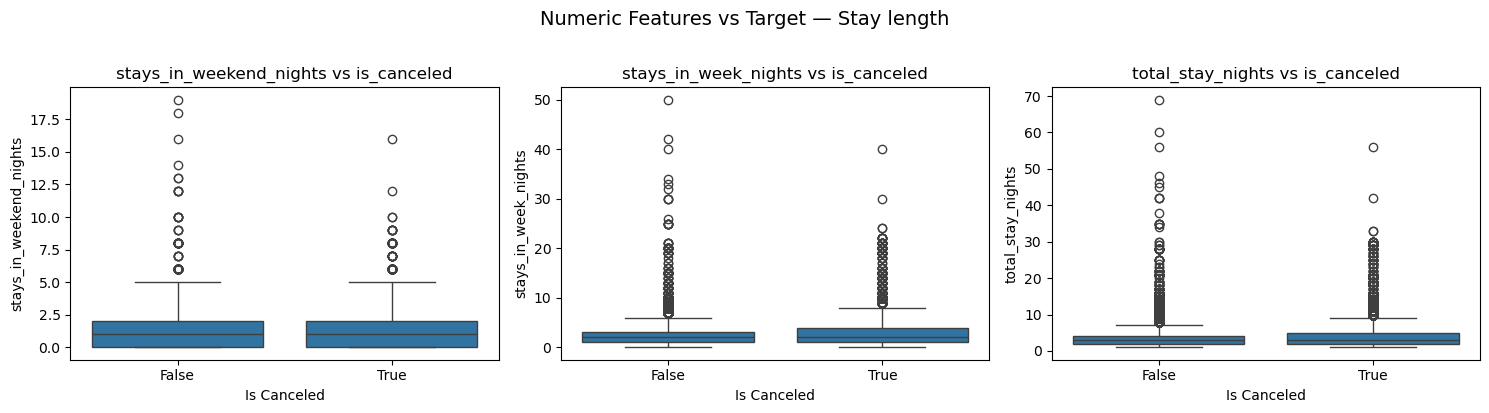

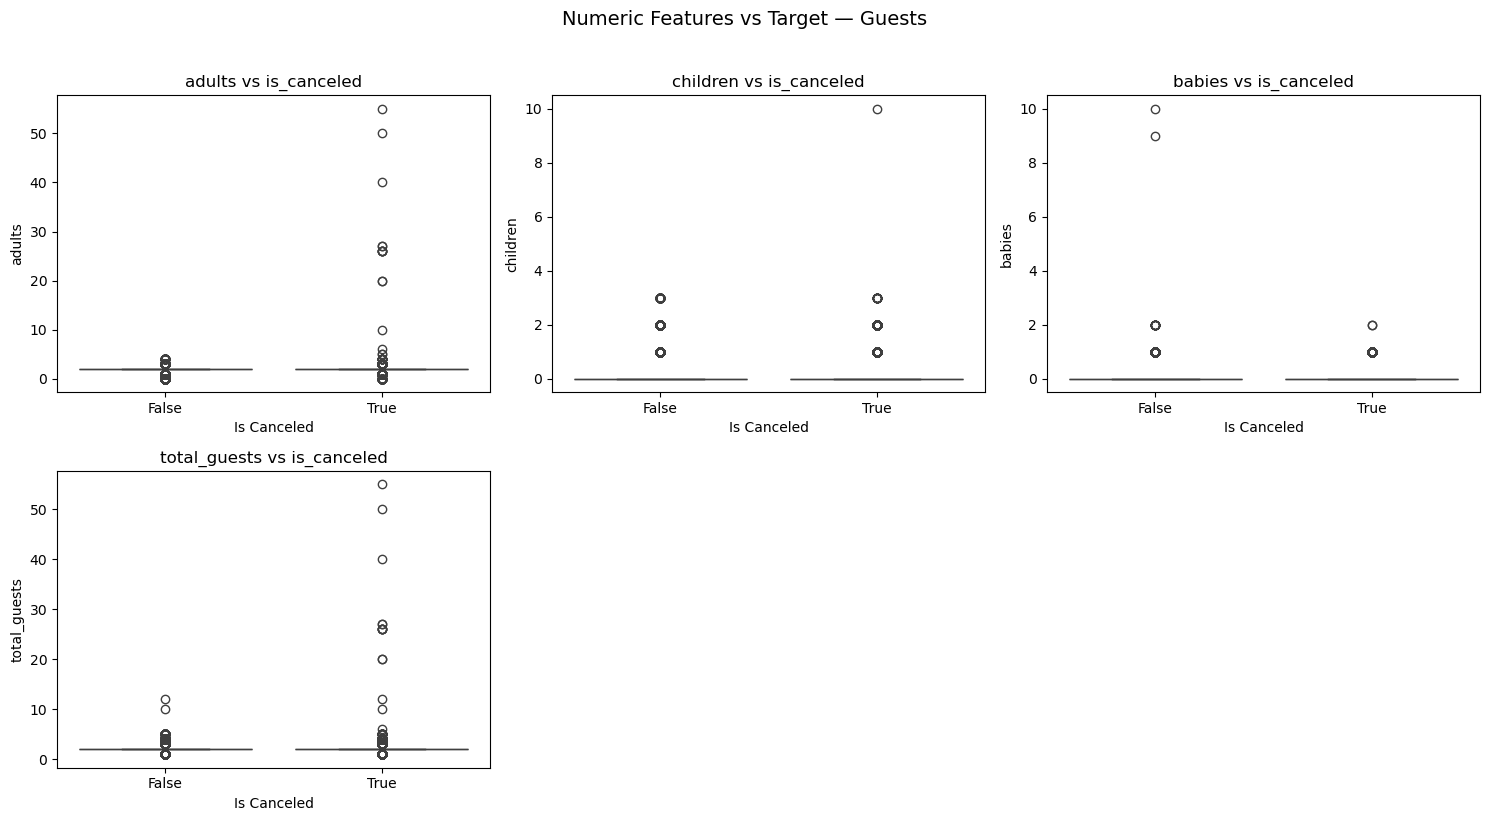

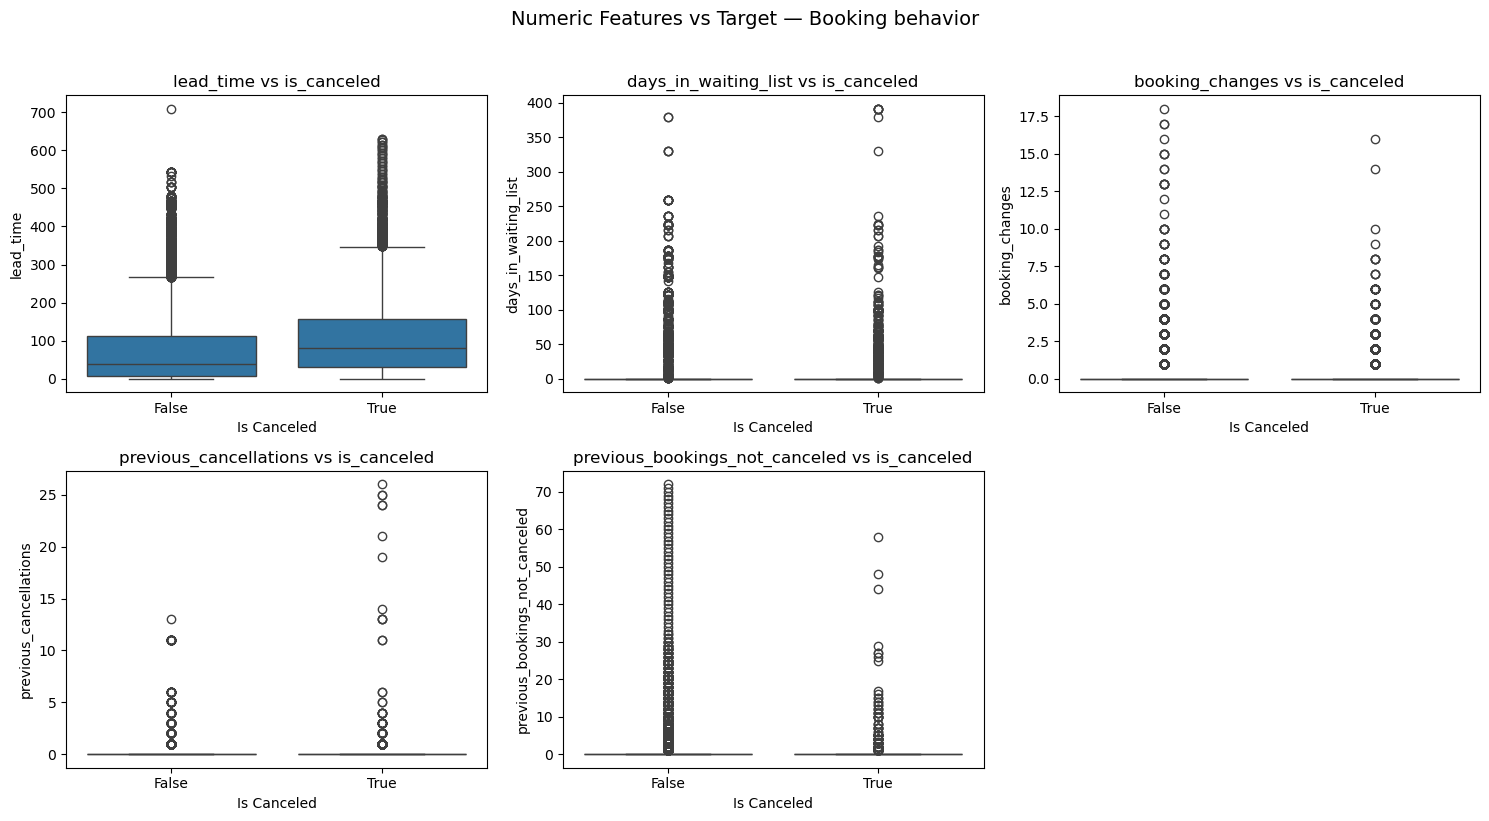

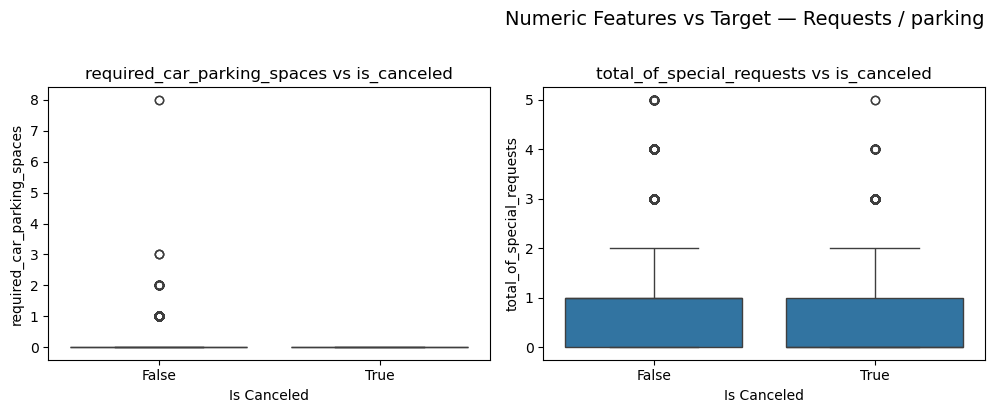

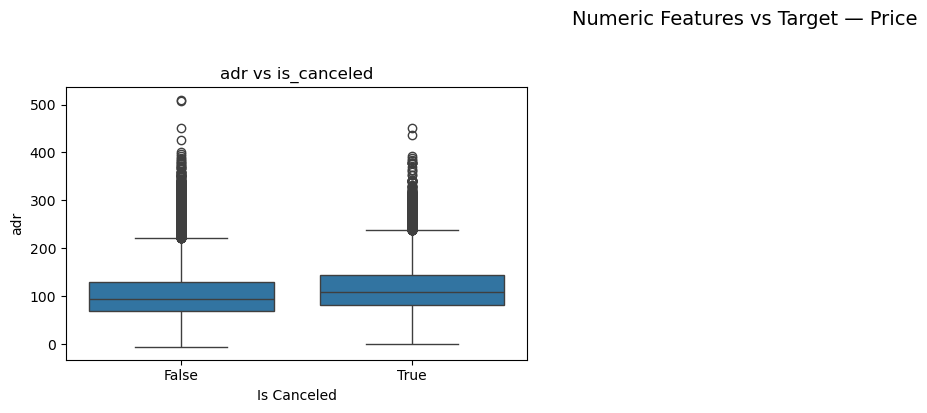

In [228]:
# ============================================
# NUMERICAL FEATURES VS TARGET
# ============================================
# make sure num_cols is a list of numeric column names
num_cols = df.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()

# groups (edit if you want)
groups = {
    "Stay length": ["stays_in_weekend_nights", "stays_in_week_nights", "total_stay_nights"],
    "Guests": ["adults", "children", "babies", "total_guests"],
    "Booking behavior": ["lead_time", "days_in_waiting_list", "booking_changes",
                         "previous_cancellations", "previous_bookings_not_canceled"],
    "Requests / parking": ["required_car_parking_spaces", "total_of_special_requests"],
    "Price": ["adr"],
}

target = "is_canceled"

# keep only columns that exist + are numeric + not target
groups = {
    g: [c for c in cols if (c in df.columns) and (c in num_cols) and (c != target)]
    for g, cols in groups.items()
}
groups = {g: cols for g, cols in groups.items() if len(cols) > 0}

cols_per_row = 3

for group_name, cols in groups.items():
    n_rows = int(np.ceil(len(cols) / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5 * cols_per_row, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(cols):
        sns.boxplot(x=target, y=col, data=df, ax=axes[idx])
        axes[idx].set_title(f"{col} vs {target}")
        axes[idx].set_xlabel("Is Canceled")

    # remove empty subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Numeric Features vs Target — {group_name}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()




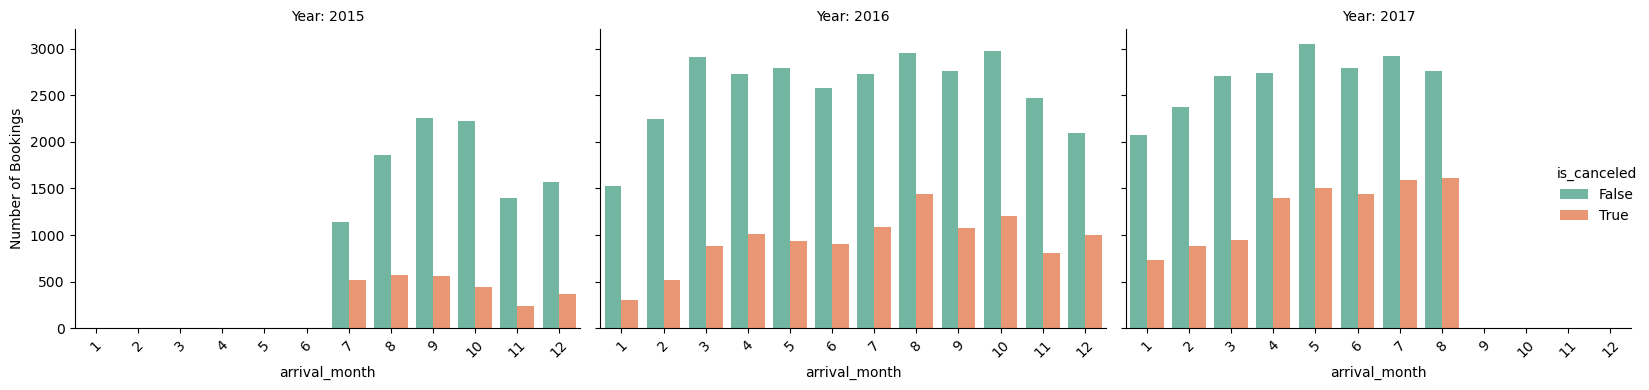

In [229]:
g = sns.catplot(
    data=df,
    x="arrival_month",
    hue="is_canceled",
    col="arrival_date_year",
    kind="count",
    palette="Set2",
    col_wrap=3,  
    height=4,
    aspect=1.3
)

g.set_xticklabels(rotation=45)
g.set_axis_labels("arrival_month", "Number of Bookings")
g.set_titles("Year: {col_name}")
plt.tight_layout()
plt.show()


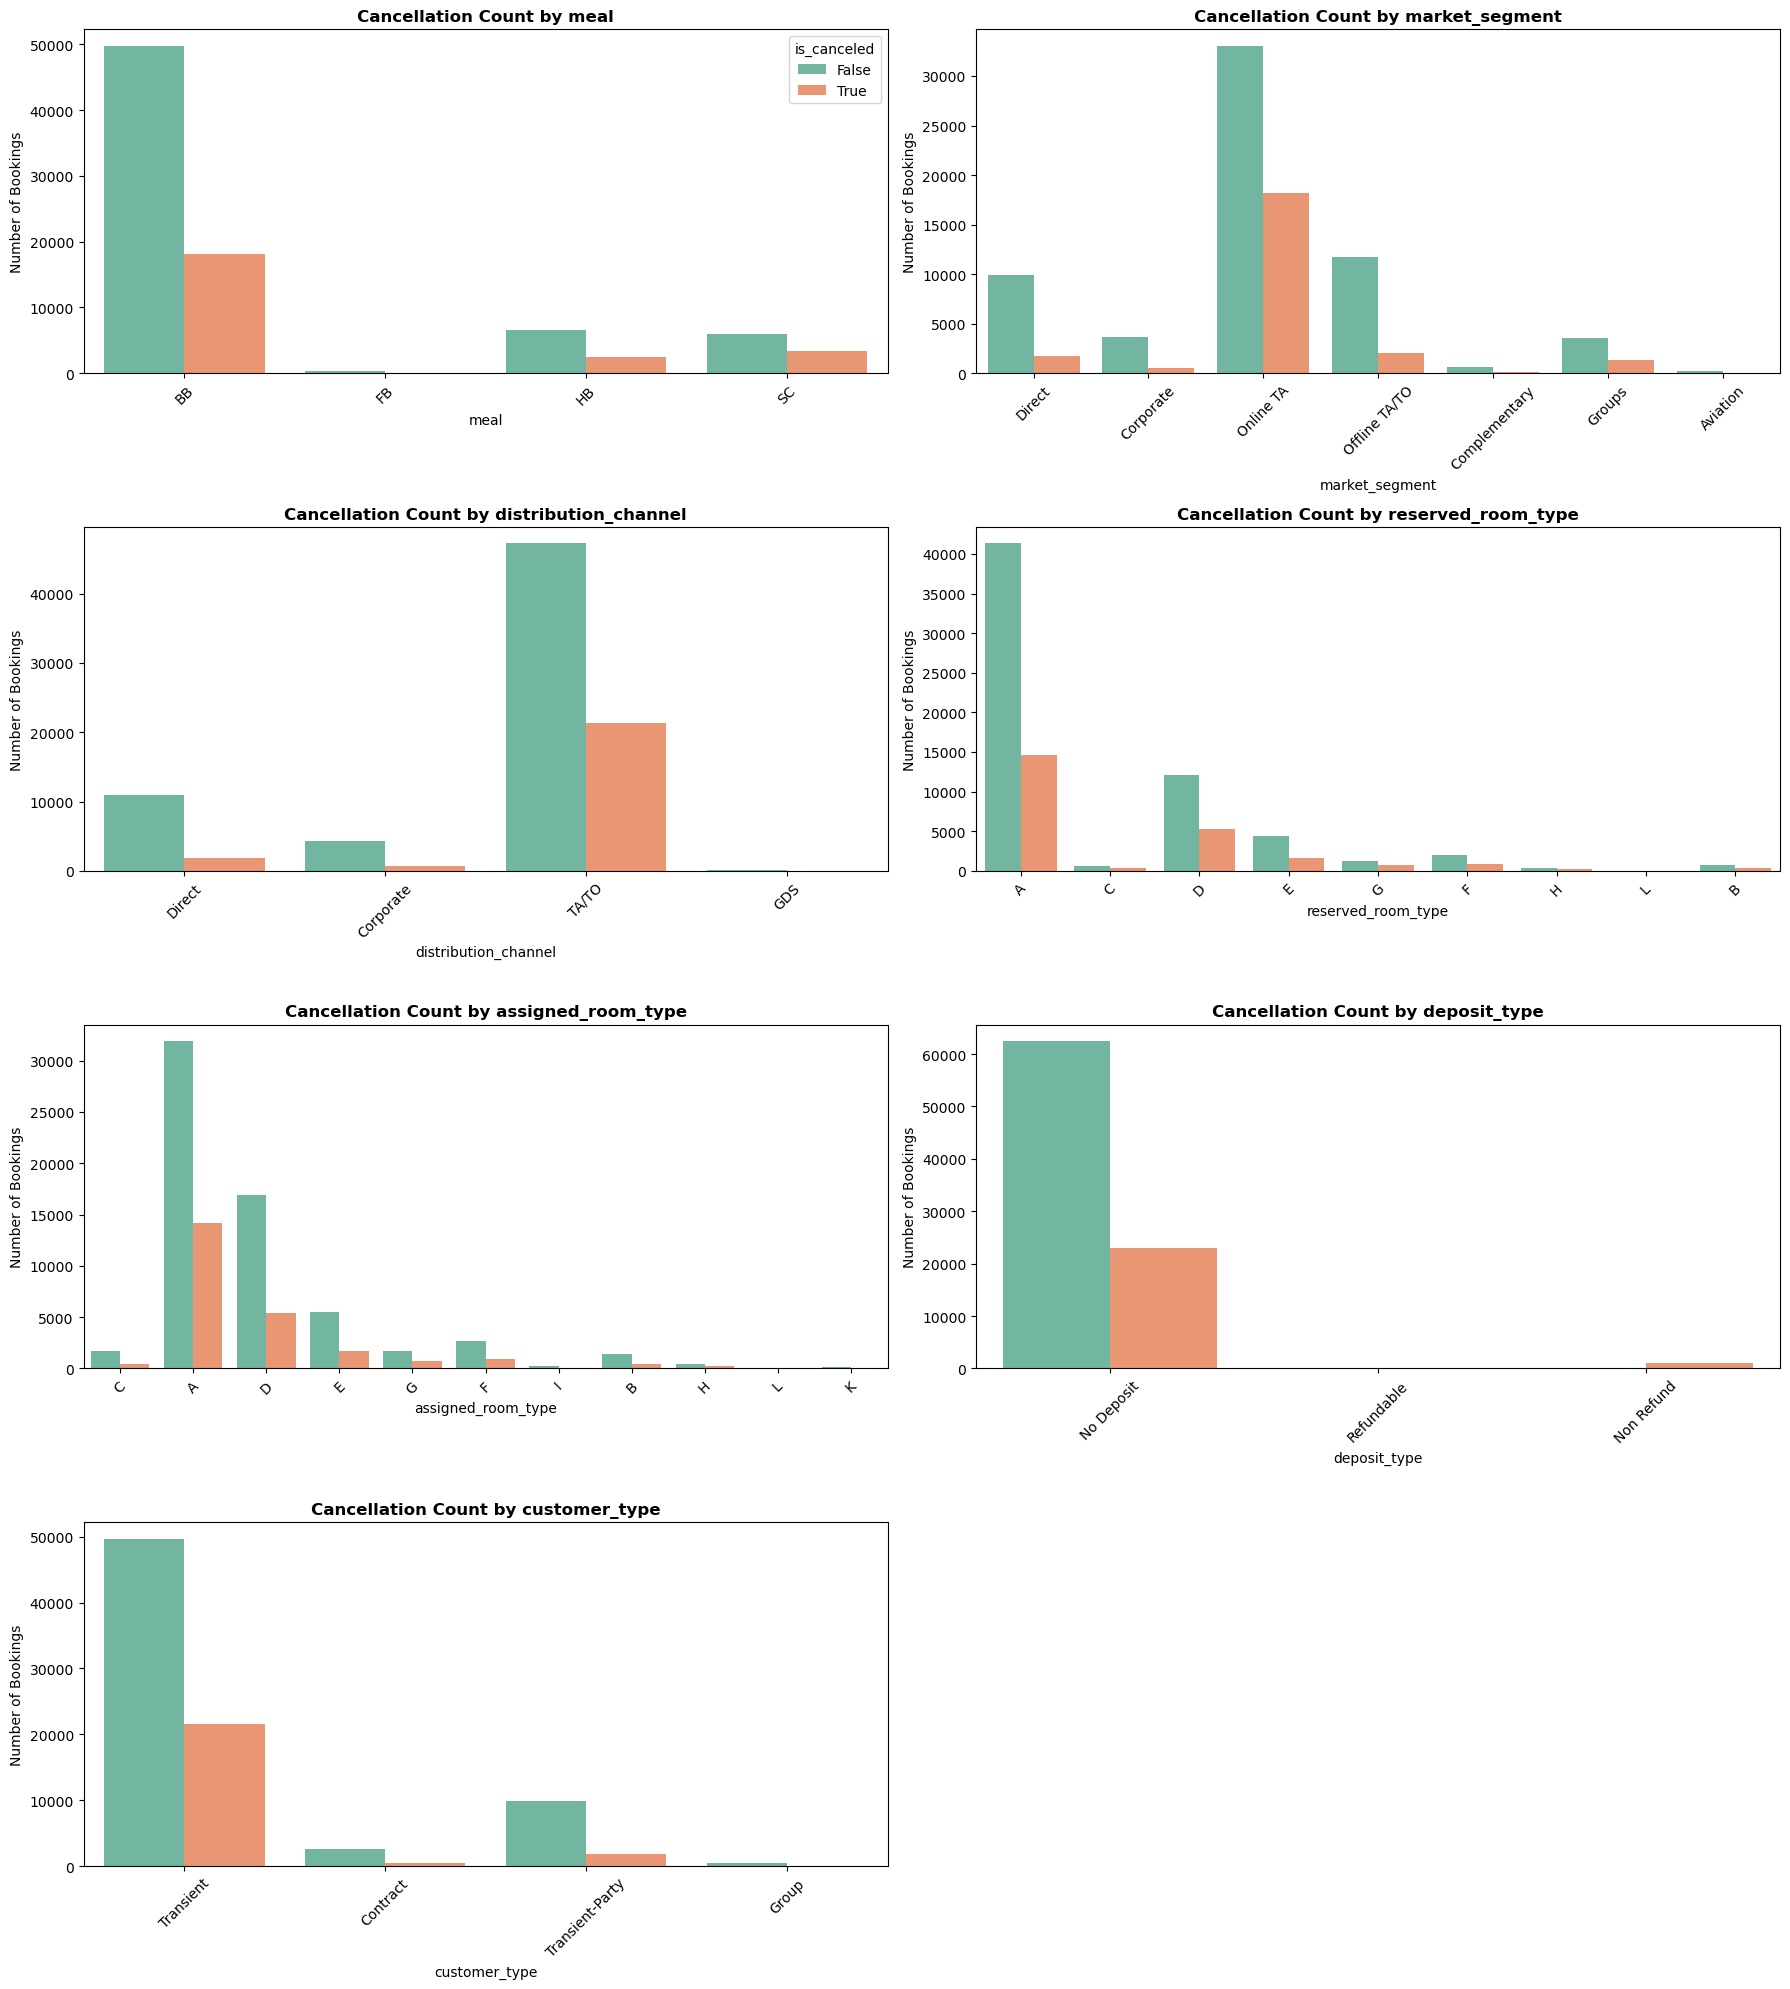

In [230]:
# ============================================
# CATEGORICAL FEATURES VS TARGET
# ============================================

cat_cols = [c for c in cat_cols if c != "is_canceled"]

ncols = 2
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()  # easier indexing

for i, col in enumerate(cat_cols):
    ax = axes[i]
    plot_df = df
    title_suffix = ""

    sns.countplot(
        data=plot_df,
        x=col,
        hue="is_canceled",
        dodge=True,
        ax=ax,
        palette="Set2"
    )

    ax.set_title(f"Cancellation Count by {col}{title_suffix}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Bookings")
    ax.tick_params(axis="x", rotation=45)

    # Optional: keep legend only on the first plot to reduce clutter
    if i != 0 and ax.get_legend() is not None:
        ax.get_legend().remove()

# remove any empty subplots if cat_cols is odd
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


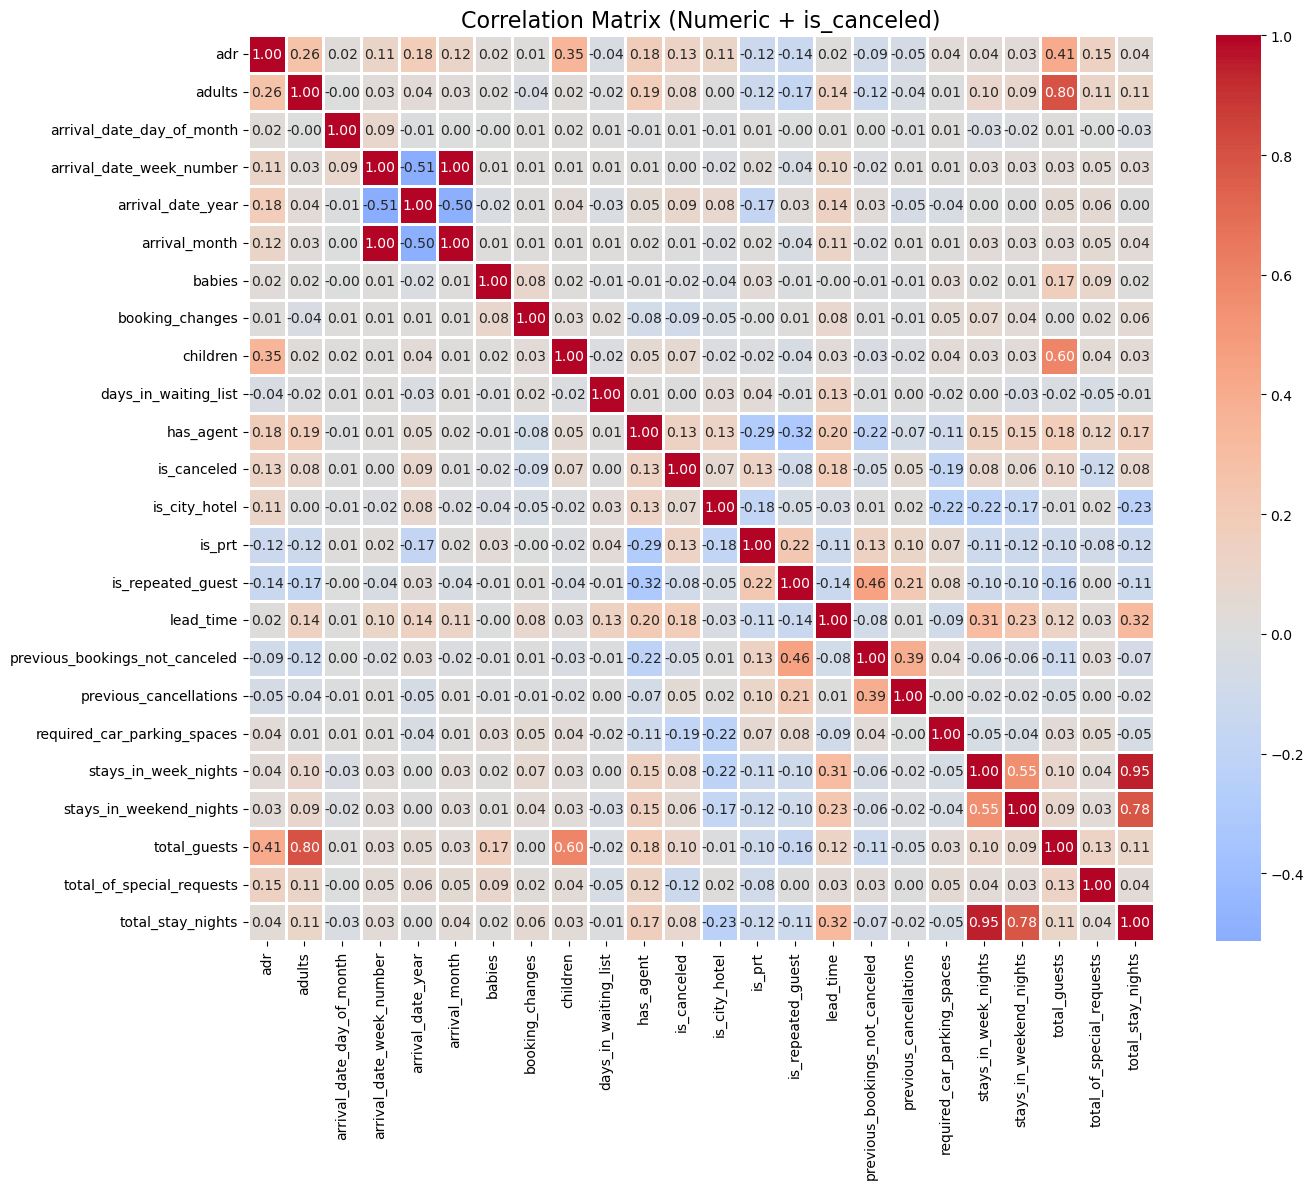

In [231]:
# ============================================
# CORRELATION WITH NUMERICAL FEATURES
# ============================================

# numeric columns only
num_cols = df.select_dtypes(include=["number",'bool']).columns

# add target (even if it's bool)
cols = num_cols.union(["is_canceled"])

df_corr = df[cols].copy()
df_corr["is_canceled"] = df_corr["is_canceled"].astype(int)  # bool -> 0/1

correlation = df_corr.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1
)
plt.title("Correlation Matrix (Numeric + is_canceled)", fontsize=16)
plt.tight_layout()
plt.show()



In [232]:
# ============================================
# CORRELATION WITH CATEGORICAL 
# ============================================
import scipy.stats as ss

def cramers_v(x, y):
    # Cross-tab
    confusion = pd.crosstab(x, y)

    # Chi-square
    chi2 = ss.chi2_contingency(confusion, correction=False)[0]
    n = confusion.to_numpy().sum()

    # Cramér’s V
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


target = "is_canceled"
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.drop(target, errors="ignore")

scores = {c: cramers_v(df[c], df[target]) for c in cat_cols}
pd.Series(scores).sort_values(ascending=False)


market_segment          0.221240
deposit_type            0.164855
distribution_channel    0.152036
has_agent               0.132411
is_prt                  0.130076
customer_type           0.127859
assigned_room_type      0.087375
is_repeated_guest       0.084362
is_city_hotel           0.070773
meal                    0.062094
reserved_room_type      0.056569
dtype: float64

# Modeling

### Evaluation Metric (Acc,AUC,REC,F1)

In [233]:
# define the function for evaluation
def get_auc_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def evaluate(model, X, y, name="Model"):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    rec = recall_score(y, y_pred)
    
    scores = get_auc_scores(model, X)
    auc = roc_auc_score(y, scores) if scores is not None else np.nan

    print(f"\n{name}")
    if not np.isnan(auc):
        print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f} | REC: {rec:.4f}")
    else:
        print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    return acc, f1, auc, rec

## Baseline model (Without hyperparameter tunning)

In [234]:
# ---------------------------
# 1) Baseline models 
# ---------------------------
lr  = LogisticRegression(max_iter=50000, n_jobs=4)
svm = LinearSVC()
rf  = RandomForestClassifier(n_jobs=4, random_state=42)
hgb = HistGradientBoostingClassifier(random_state=42)

def de_model(model, name="Model"):
    pipe = Pipeline([
        ("smote", smotenc),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    tr_acc, tr_f1, tr_auc, tr_rec = evaluate(pipe, X_train, y_train, f"{name} (Train)")
    va_acc, va_f1, va_auc, va_rec = evaluate(pipe, X_val, y_val, f"{name} (Val)")

    return tr_acc, tr_f1, tr_auc, tr_rec, va_acc, va_f1, va_auc, va_rec


In [235]:
lr_tr_acc, lr_tr_f1, lr_tr_auc, lr_tr_rec, lr_va_acc, lr_va_f1, lr_va_auc, lr_va_rec = de_model(lr, "Logistic Regression")
svm_tr_acc, svm_tr_f1, svm_tr_auc, svm_tr_rec, svm_va_acc, svm_va_f1, svm_va_auc, svm_va_rec = de_model(svm, "SVM")
rf_tr_acc, rf_tr_f1, rf_tr_auc, rf_tr_rec, rf_va_acc, rf_va_f1, rf_va_auc, rf_va_rec = de_model(rf, "Random Forest")
hgb_tr_acc, hgb_tr_f1, hgb_tr_auc, hgb_tr_rec, hgb_va_acc, hgb_va_f1, hgb_va_auc, hgb_va_rec = de_model(hgb, "HistGradientBoosting")


Logistic Regression (Train)
Accuracy: 0.7625 | F1: 0.5974 | ROC-AUC: 0.8063 | REC: 0.6365

Logistic Regression (Val)
Accuracy: 0.7633 | F1: 0.5952 | ROC-AUC: 0.8069 | REC: 0.6286

SVM (Train)
Accuracy: 0.7570 | F1: 0.5819 | ROC-AUC: 0.7922 | REC: 0.6109

SVM (Val)
Accuracy: 0.7603 | F1: 0.5834 | ROC-AUC: 0.7947 | REC: 0.6061

Random Forest (Train)
Accuracy: 0.9968 | F1: 0.9943 | ROC-AUC: 0.9999 | REC: 0.9932

Random Forest (Val)
Accuracy: 0.8373 | F1: 0.6913 | ROC-AUC: 0.8968 | REC: 0.6582

HistGradientBoosting (Train)
Accuracy: 0.8424 | F1: 0.7053 | ROC-AUC: 0.9074 | REC: 0.6813

HistGradientBoosting (Val)
Accuracy: 0.8341 | F1: 0.6900 | ROC-AUC: 0.8977 | REC: 0.6665


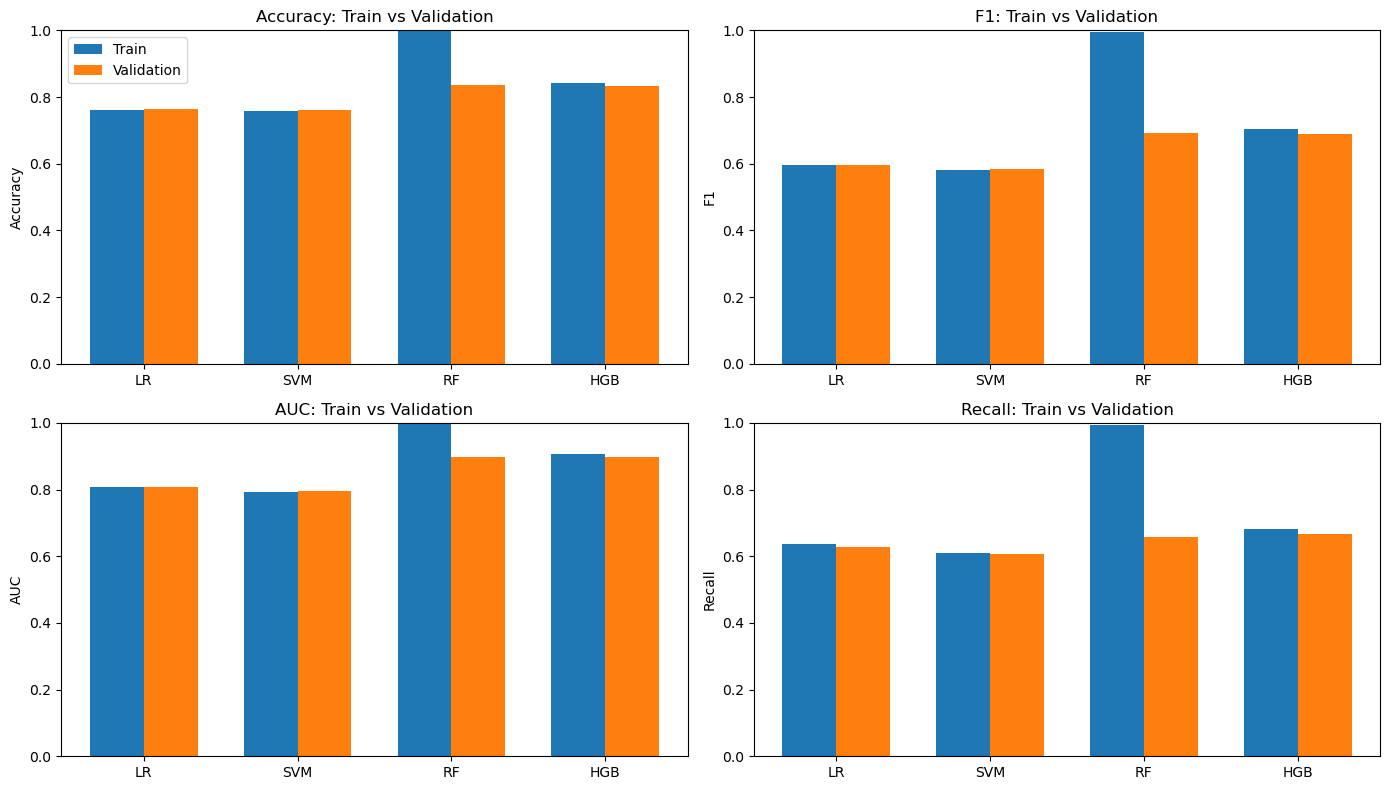

In [236]:
# visualise the result
models = ["LR", "SVM", "RF", "HGB"]

train = {
    "Accuracy": [lr_tr_acc, svm_tr_acc, rf_tr_acc, hgb_tr_acc],
    "F1":       [lr_tr_f1,  svm_tr_f1,  rf_tr_f1,  hgb_tr_f1],
    "AUC":      [lr_tr_auc, svm_tr_auc, rf_tr_auc, hgb_tr_auc],
    "Recall":   [lr_tr_rec, svm_tr_rec, rf_tr_rec, hgb_tr_rec],
}

val = {
    "Accuracy": [lr_va_acc, svm_va_acc, rf_va_acc, hgb_va_acc],
    "F1":       [lr_va_f1,  svm_va_f1,  rf_va_f1,  hgb_va_f1],
    "AUC":      [lr_va_auc, svm_va_auc, rf_va_auc, hgb_va_auc],
    "Recall":   [lr_va_rec, svm_va_rec, rf_va_rec, hgb_va_rec],
}

metrics = list(train.keys())
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]

    bars_train = ax.bar(x - width/2, train[m], width, label="Train")
    bars_val   = ax.bar(x + width/2, val[m],   width, label="Validation")

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)
    ax.set_title(f"{m}: Train vs Validation")
    ax.set_ylabel(m)

    if i == 0:  # show legend once
        ax.legend()

plt.tight_layout()
plt.show()

### Hyperparameter tunning (RF and XGBoost) [Top 2 performance model only]

In [237]:
# ---------------------------
# 2) Hyperparameter tuning (top 2 models)
# ---------------------------
from sklearn.model_selection import RandomizedSearchCV

def tune_model(model, param_grid, X_train, y_train, X_val, y_val, name="Model"):
    # The Pipeline structure remains the same
    pipe = Pipeline([("smote", smotenc), ("model", model)])
    
    # 1. Switched to RandomizedSearchCV
    # 2. n_iter=10 (controls how many random combinations to try)
    # 3. n_jobs=-1 (uses all available CPU cores)
    rs = RandomizedSearchCV(
        pipe, 
        param_distributions=param_grid, 
        n_iter=10, 
        scoring="f1", 
        cv=3, 
        n_jobs=-1, 
        refit=True,
        random_state=42
    )
    
    rs.fit(X_train, y_train)

    print(f"[{name}] best params:", rs.best_params_)

    best_model = rs.best_estimator_
    
    # Evaluation
    tr_acc, tr_f1, tr_auc, tr_rec = evaluate(best_model, X_train, y_train, f"{name} (Train, in-sample)")
    va_acc, va_f1, va_auc, va_rec = evaluate(best_model, X_val, y_val, f"{name} (Val)")
    
    return best_model, tr_acc, tr_f1, tr_auc, tr_rec, va_acc, va_f1, va_auc, va_rec

In [238]:
#define the grid for random forest and HGB
rf_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [10, 20],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", "log2",None],
}

hgb_grid = {
    "model__max_iter": [200, 500],          
    "model__max_depth": [3, 6, 10],         
    "model__learning_rate": [0.01, 0.2],    
    "model__max_leaf_nodes": [31, 63],      
    "model__min_samples_leaf": [20, 50],    
    "model__l2_regularization": [0.0, 0.1], 
}

In [239]:
best_pipe_rf, rf_tr_acc, rf_tr_f1, rf_tr_auc, rf_tr_rec, rf_va_acc, rf_va_f1, rf_va_auc, rf_va_rec = tune_model(
    rf, rf_grid, X_train, y_train, X_val, y_val, name="RF pipeline"
)

best_pipe_hgb, hgb_tr_acc, hgb_tr_f1, hgb_tr_auc, hgb_tr_rec, hgb_va_acc, hgb_va_f1, hgb_va_auc, hgb_va_rec = tune_model(
    hgb, hgb_grid, X_train, y_train, X_val, y_val, name="HGB pipeline"
)

[RF pipeline] best params: {'model__n_estimators': 200, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': None, 'model__max_depth': None}

RF pipeline (Train, in-sample)
Accuracy: 0.9043 | F1: 0.8255 | ROC-AUC: 0.9672 | REC: 0.8176

RF pipeline (Val)
Accuracy: 0.8348 | F1: 0.7006 | ROC-AUC: 0.8974 | REC: 0.6978
[HGB pipeline] best params: {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 31, 'model__max_iter': 200, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__l2_regularization': 0.0}

HGB pipeline (Train, in-sample)
Accuracy: 0.8641 | F1: 0.7470 | ROC-AUC: 0.9312 | REC: 0.7248

HGB pipeline (Val)
Accuracy: 0.8393 | F1: 0.7009 | ROC-AUC: 0.9045 | REC: 0.6799


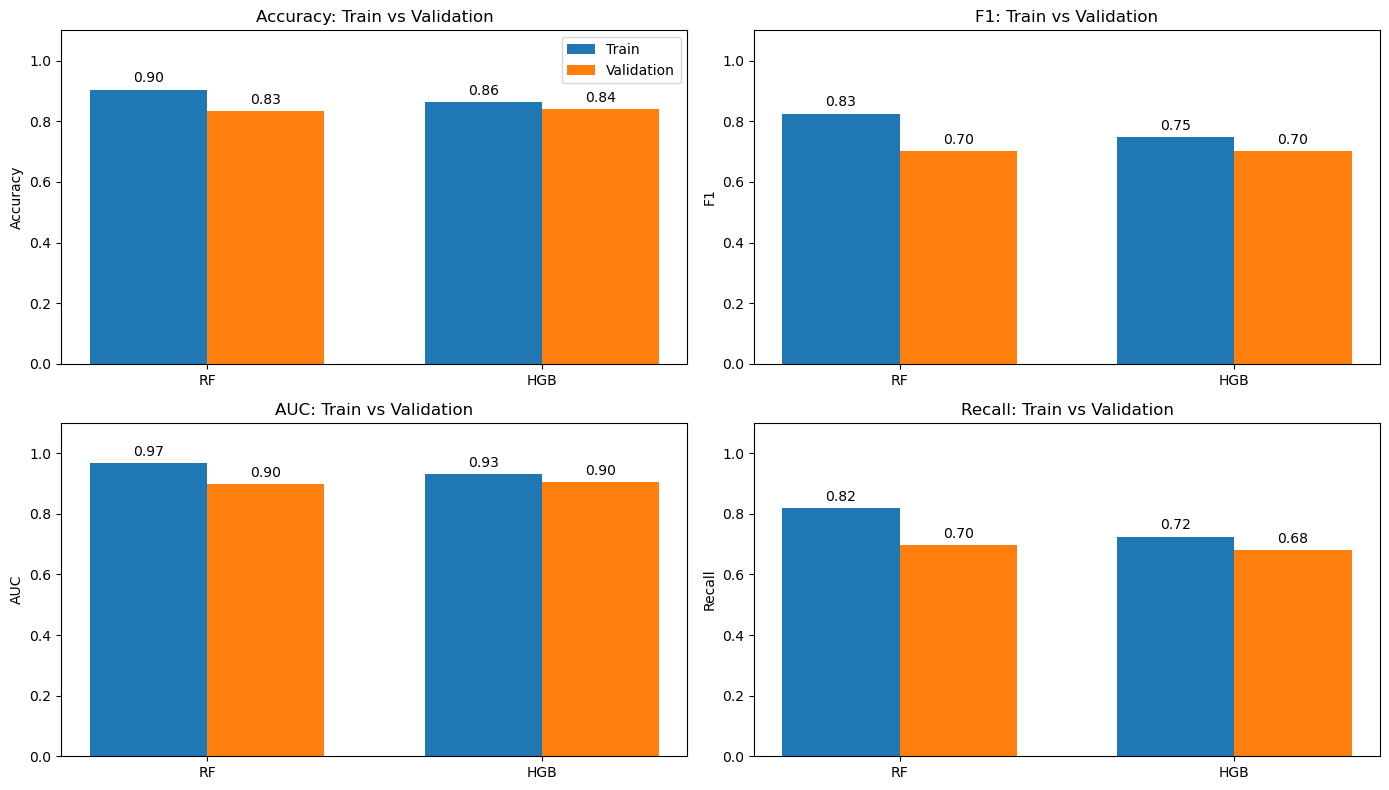

In [240]:
#visualise the result
models = ["RF", "HGB"]

train = {
    "Accuracy": [rf_tr_acc, hgb_tr_acc],
    "F1":       [rf_tr_f1,  hgb_tr_f1],
    "AUC":      [rf_tr_auc, hgb_tr_auc],
    "Recall":   [rf_tr_rec, hgb_tr_rec],
}

val = {
    "Accuracy": [rf_va_acc, hgb_va_acc],
    "F1":       [rf_va_f1,  hgb_va_f1],
    "AUC":      [rf_va_auc, hgb_va_auc],
    "Recall":   [rf_va_rec, hgb_va_rec],
}

metrics = list(train.keys())
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]

    bars_train = ax.bar(x - width/2, train[m], width, label="Train")
    bars_val   = ax.bar(x + width/2, val[m],   width, label="Validation")

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1)  # Increased limit slightly for labels
    ax.set_title(f"{m}: Train vs Validation")
    ax.set_ylabel(m)
    
    # Adding data labels for clarity
    ax.bar_label(bars_train, fmt='%.2f', padding=3)
    ax.bar_label(bars_val, fmt='%.2f', padding=3)

    if i == 0:  # show legend once
        ax.legend()

plt.tight_layout()
plt.show()

### Train and test the final model for application used

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      6266
           1       0.73      0.67      0.70      2398

    accuracy                           0.84      8664
   macro avg       0.80      0.79      0.79      8664
weighted avg       0.84      0.84      0.84      8664


Best HGB (Test)
Accuracy: 0.8391 | F1: 0.6987 | ROC-AUC: 0.9028 | REC: 0.6739


<Figure size 500x400 with 0 Axes>

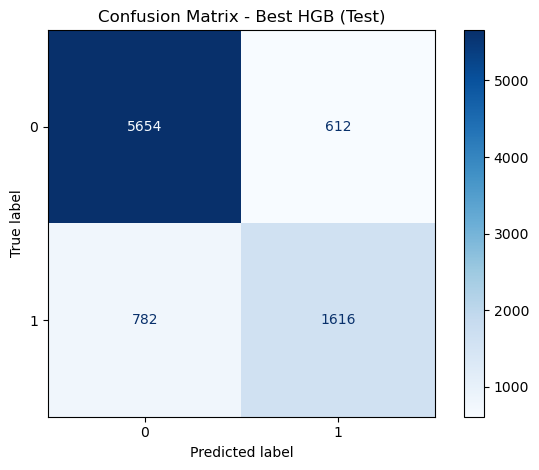

In [241]:
# ---------------------------
# 3) Final training + test evaluation
# ---------------------------
hgb_best = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=6,
    max_iter=500,       
    random_state=42
)

pipe = Pipeline([("smote", smotenc), ("model", hgb_best)])
pipe.fit(X_train, y_train)

y_pred_test = pipe.predict(X_test)
print(classification_report(y_test, y_pred_test))

acc, f1, auc, rec = evaluate(pipe, X_test, y_test, name="Best HGB (Test)")

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(5, 4))
disp.plot(values_format="d", cmap="Blues") 
plt.title("Confusion Matrix - Best HGB (Test)")
plt.tight_layout()
plt.show()

### Feature Selection (Select top 10 feature that is important for HGB to predict the hotel cancellation)

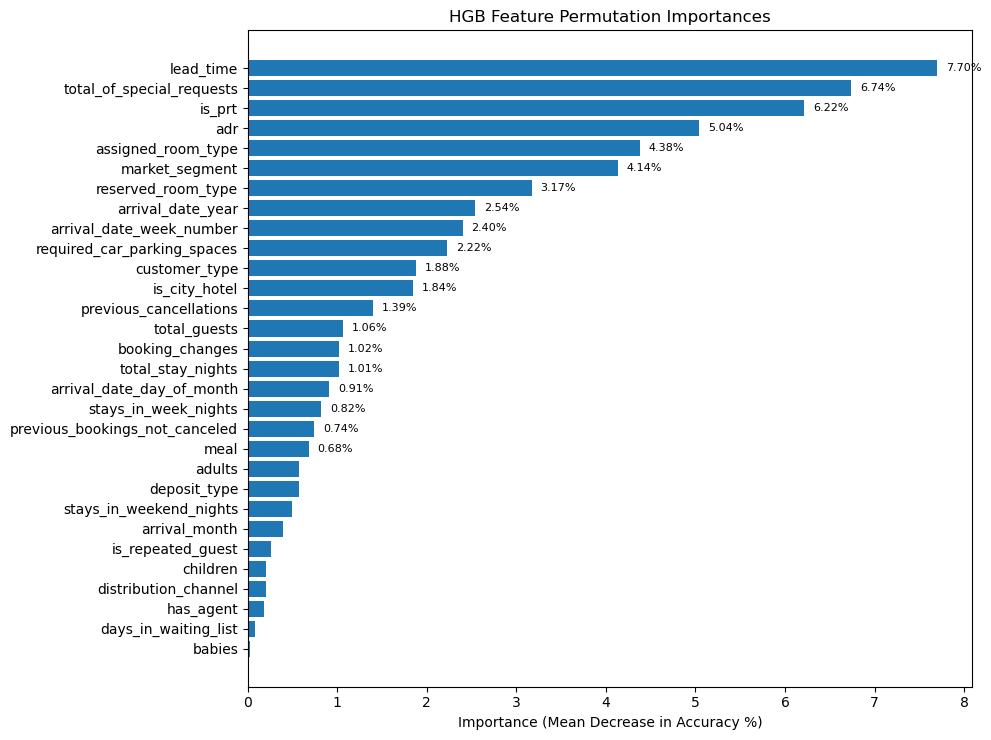

In [242]:
from sklearn.inspection import permutation_importance

# ---------------------------
# Visualise Feature Importance (HGB)
# ---------------------------

permutation_result = permutation_importance(
    pipe, X_train, y_train, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# Use the mean importance (decrease in score)
imp = perm_result.importances_mean

df_all = pd.DataFrame({
    "feature": X_train.columns,
    "importance": imp
}).sort_values("importance", ascending=True)

# Convert to percentage (e.g., 0.05 importance -> 5% drop in accuracy)
df_all["percent"] = df_all["importance"] * 100

plt.figure(figsize=(10, max(6, 0.25 * len(df_all))))  # auto height
bars = plt.barh(df_all["feature"], df_all["percent"])
plt.xlabel("Importance (Mean Decrease in Accuracy %)")
plt.title("HGB Feature Permutation Importances")

# Label only the largest 20
top_k_labels = 20
for b, v, name in zip(bars, df_all["percent"], df_all["feature"]):
    if name in df_all.tail(top_k_labels)["feature"].values:
        # Add a small buffer to text position
        plt.text(max(0, b.get_width()) + 0.1, b.get_y() + b.get_height()/2, 
                 f"{v:.2f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [243]:
#select the top 10 only
top_idx = np.argsort(imp)[::-1][:10]
top_features = X_train.columns[top_idx].tolist()
top_features

['lead_time',
 'total_of_special_requests',
 'is_prt',
 'adr',
 'assigned_room_type',
 'market_segment',
 'reserved_room_type',
 'arrival_date_year',
 'arrival_date_week_number',
 'required_car_parking_spaces']

# for application 

In [244]:
# top features
top_features = ['lead_time',
                 'total_of_special_requests',
                 'is_prt',
                 'adr',
                 'assigned_room_type',
                 'market_segment',
                 'reserved_room_type',
                 'arrival_date_year',
                 'arrival_date_week_number',
                 'required_car_parking_spaces'
               ]
X_train_top = ori_X_train[top_features].copy()
int_cols_top = X_train_top.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_top = X_train_top.select_dtypes(include=["object", "category"]).columns.tolist()

label_encoders = {}
for col in cat_cols_top:
    le = LabelEncoder()
    X_train_top[col] = le.fit_transform(X_train_top[col].astype(str))
    label_encoders[col] = le

scaler = MinMaxScaler()
X_train_top[int_cols_top] = scaler.fit_transform(X_train_top[int_cols_top])

cat_idx_top = [X_train_top.columns.get_loc(c) for c in cat_cols_top]

smotenc_top = SMOTENC(categorical_features=cat_idx_top,random_state=42,k_neighbors=5,sampling_strategy=0.7)

top_pipe = Pipeline([
    ("smote", smotenc_top),
    ("model", clone(hgb_best))
])

top_pipe.fit(X_train_top, y_train)

Pipeline(steps=[('smote',
                 SMOTENC(categorical_features=[4, 5, 6], random_state=42,
                         sampling_strategy=0.7)),
                ('model',
                 HistGradientBoostingClassifier(max_depth=6, max_iter=500,
                                                random_state=42))])

In [245]:
# if the top n include different categorical data from below, change it
wanted = {"reserved_room_type", "market_segment", "assigned_room_type"}

for col, le in label_encoders.items():
    if col in wanted:
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"\n{col} mapping:")
        for k, v in mapping.items():
            print(f"  {k} -> {v}")


assigned_room_type mapping:
  A -> 0
  B -> 1
  C -> 2
  D -> 3
  E -> 4
  F -> 5
  G -> 6
  H -> 7
  I -> 8
  K -> 9
  L -> 10

market_segment mapping:
  Aviation -> 0
  Complementary -> 1
  Corporate -> 2
  Direct -> 3
  Groups -> 4
  Offline TA/TO -> 5
  Online TA -> 6

reserved_room_type mapping:
  A -> 0
  B -> 1
  C -> 2
  D -> 3
  E -> 4
  F -> 5
  G -> 6
  H -> 7
  L -> 8


In [246]:
INT_COLS  = {"lead_time","arrival_date_year","arrival_date_week_number","required_car_parking_spaces","total_of_special_requests"}
CAT_COLS = {"reserved_room_type", "market_segment", "assigned_room_type"}
BIN_COLS = {"is_prt"}
CONT_COLS = {"adr"} 

def ask_float(name, min_val=None):
    while True:
        try:
            v = float(input(f"{name} (float): ").strip())
            if min_val is not None and v < min_val:
                print(f"  Must be >= {min_val}")
                continue
            return v
        except ValueError:
            print("  Please enter a valid number (e.g. 12.50).")

def ask_int(name, min_val=None):
    while True:
        try:
            v = int(input(f"{name} (integer): ").strip())
            if min_val is not None and v < min_val:
                print(f"  Must be >= {min_val}")
                continue
            return v
        except ValueError:
            print("  Please enter an integer.")

def ask_bin(name):
    while True:
        s = input(f"{name} (0 or 1): ").strip().lower()
        if s in {"0", "1"}:
            return int(s)
        print("  Enter 0 or 1.")

def ask_cat_number_only(col, label_encoders):
    # Ensure the encoder exists for this column
    if col not in label_encoders:
        print(f"Warning: No encoder found for {col}, returning 0")
        return 0
        
    le = label_encoders[col]
    classes = list(le.classes_)

    print(f"\nChoose {col} (enter a number):")
    for i, cls in enumerate(classes):
        print(f"  {i}: {cls}")

    while True:
        s = input(f"Enter {col} code (0-{len(classes)-1}): ").strip()
        if s.isdigit():
            idx = int(s)
            if 0 <= idx < len(classes):
                # Return the integer index (since model is trained on LabelEncoded ints)
                return idx 
        print("  Invalid. Please enter one of the numbers shown.")

def get_user_row(label_encoders):
    row = {}
    for col in top_features:
        if col in INT_COLS:
            row[col] = ask_int(col, min_val=0)
        elif col in BIN_COLS:
            row[col] = ask_bin(col)
        elif col in CAT_COLS:
            row[col] = ask_cat_number_only(col, label_encoders)
        elif col in CONT_COLS:
            # Added handler for Continuous columns
            row[col] = ask_float(col, min_val=0.0)
        else:
            # Fallback for unexpected columns
            print(f"Warning: Column '{col}' type unknown, treating as string.")
            row[col] = input(f"{col}: ").strip()
            
    # Create DataFrame
    df_user = pd.DataFrame([row], columns=top_features)
    
    return df_user

In [247]:
X_user = get_user_row(label_encoders)
# use minmax which also used in the preprocessing step
X_user_scaled = X_user.copy()
X_user_scaled[int_cols_top] = scaler.transform(X_user_scaled[int_cols_top])

lead_time (integer):  1
total_of_special_requests (integer):  2
is_prt (0 or 1):  1
adr (float):  3.0



Choose assigned_room_type (enter a number):
  0: A
  1: B
  2: C
  3: D
  4: E
  5: F
  6: G
  7: H
  8: I
  9: K
  10: L


Enter assigned_room_type code (0-10):  A


  Invalid. Please enter one of the numbers shown.


Enter assigned_room_type code (0-10):  0



Choose market_segment (enter a number):
  0: Aviation
  1: Complementary
  2: Corporate
  3: Direct
  4: Groups
  5: Offline TA/TO
  6: Online TA


Enter market_segment code (0-6):  0



Choose reserved_room_type (enter a number):
  0: A
  1: B
  2: C
  3: D
  4: E
  5: F
  6: G
  7: H
  8: L


Enter reserved_room_type code (0-8):  0
arrival_date_year (integer):  0
arrival_date_week_number (integer):  0
required_car_parking_spaces (integer):  1


In [249]:
#pred
pred = top_pipe.predict(X_user_scaled)[0]
if pred == 1:
    word = 'cancel'
elif pred == 0:
    word = 'not cancel'
print(f'The user will {word} booking')

The user will not cancel booking
